1. Predicting SalePrice

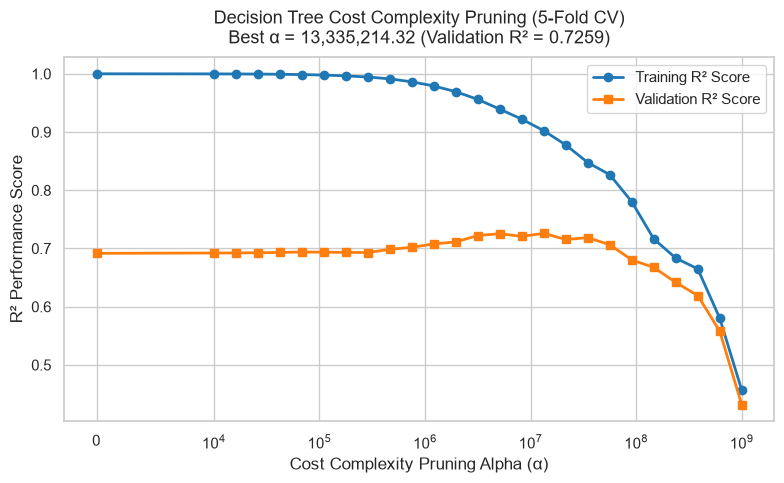

Optimal Alpha: 13,335,214.32
Optimal Validation R2: 0.7259


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y)
# Drop categorical labels to prevent target leakage
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['SalePrice']

# 2. Define a refined, wide-spectrum alpha range for testing
# Using logspace because the cost complexity path spans several orders of magnitude
refined_alphas = np.logspace(4, 9, num=25)
refined_alphas = np.insert(refined_alphas, 0, 0.0) # Ensure unpruned 0.0 is included

# 3. Setup and execute the 5-Fold Cross Validation Grid Search
dt_regressor = DecisionTreeRegressor(random_state=42)
param_grid = {'ccp_alpha': refined_alphas}

grid_search = GridSearchCV(dt_regressor, param_grid, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

# 4. Extract performance tracking metrics
results = grid_search.cv_results_
train_scores = results['mean_train_score']
val_scores = results['mean_test_score']
best_alpha = grid_search.best_params_['ccp_alpha']
best_score = grid_search.best_score_

# 5. Plot Training vs. Validation R² Curves
plt.rc('font', size=11)
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(refined_alphas, train_scores, marker='o', label='Training R² Score', color='#1f77b4', linewidth=2)
ax.plot(refined_alphas, val_scores, marker='s', label='Validation R² Score', color='#ff7f0e', linewidth=2)

# Use 'symlog' scale to cleanly display 0.0 alongside values in the millions
ax.set_xscale('symlog', linthresh=1e4)
ax.set_xlabel('Cost Complexity Pruning Alpha (α)', fontsize=12)
ax.set_ylabel('R² Performance Score', fontsize=12)
ax.set_title(f'Decision Tree Cost Complexity Pruning (5-Fold CV)\nBest α = {best_alpha:,.2f} (Validation R² = {best_score:.4f})', fontsize=13, pad=10)
ax.legend(frameon=True)
plt.tight_layout()

# Save image locally
plt.show()

print(f"Optimal Alpha: {best_alpha:,.2f}")
print(f"Optimal Validation R2: {best_score:.4f}")

2. Predicting Price_Category

Total unique pruning alphas discovered: 91


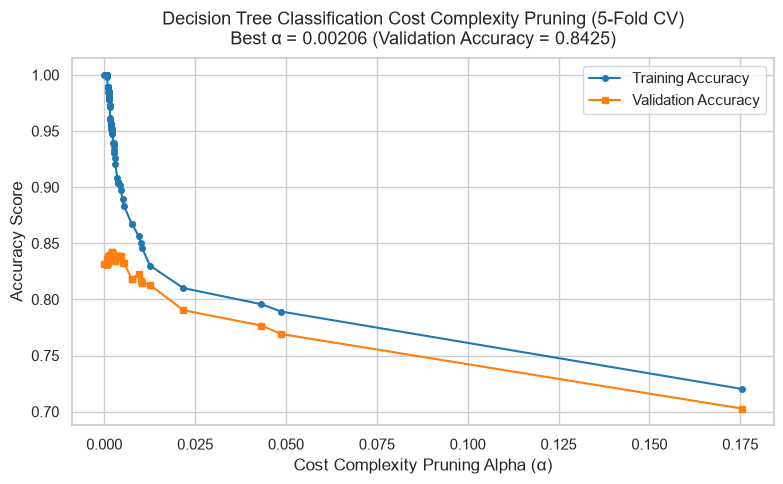

Optimal Alpha: 0.00206
Optimal Cross-Validation Accuracy: 0.8425


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y)
# Drop SalePrice to prevent deterministic target leakage
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['Price_Category']

# 2. Extract the exact cost complexity pruning path to find critical alphas
path_full = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X, y)
alphas_full = path_full.ccp_alphas

print(f"Total unique pruning alphas discovered: {len(alphas_full)}")

# 3. Setup and execute the 5-Fold Cross Validation Grid Search
clf_dt = DecisionTreeClassifier(random_state=42)
param_grid = {'ccp_alpha': alphas_full}

grid_search = GridSearchCV(clf_dt, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

# 4. Extract performance tracking metrics
results = grid_search.cv_results_
train_accuracies = results['mean_train_score']
val_accuracies = results['mean_test_score']
best_alpha = grid_search.best_params_['ccp_alpha']
best_score = grid_search.best_score_

# 5. Plot Training vs. Validation Accuracy Curves
plt.rc('font', size=11)
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas_full, train_accuracies, marker='o', label='Training Accuracy', color='#1f77b4', linewidth=1.5, markersize=4)
ax.plot(alphas_full, val_accuracies, marker='s', label='Validation Accuracy', color='#ff7f0e', linewidth=1.5, markersize=4)

ax.set_xlabel('Cost Complexity Pruning Alpha (α)', fontsize=12)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title(f'Decision Tree Classification Cost Complexity Pruning (5-Fold CV)\nBest α = {best_alpha:.5f} (Validation Accuracy = {best_score:.4f})', fontsize=13, pad=10)
ax.legend(frameon=True)
plt.tight_layout()

# Save the diagnostic visualization
plt.show()

print(f"Optimal Alpha: {best_alpha:.5f}")
print(f"Optimal Cross-Validation Accuracy: {best_score:.4f}")